In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Dataset path:", path)
print(os.listdir(path))

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
csv_file = os.path.join(path, "spam.csv")

df = pd.read_csv(csv_file, encoding="latin-1")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df = df[['v1','v2']]

In [ ]:
df.columns = ['label','email']

In [ ]:
df.head()

,label,email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.isnull().sum()

,0
label,0
email,0


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


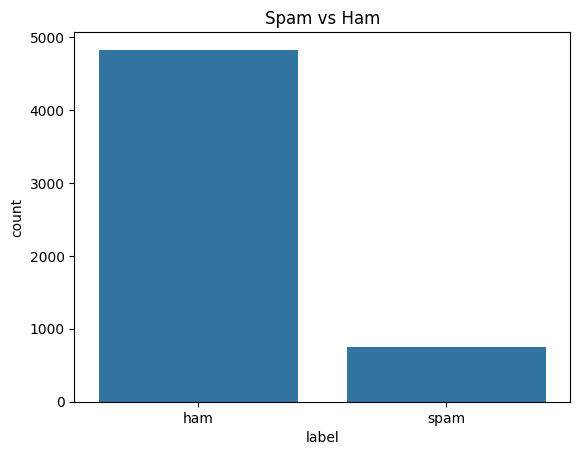

In [ ]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham")
plt.show()

In [ ]:
stemmer = PorterStemmer()
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()

    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df['clean_email'] = df['email'].apply(preprocess)

In [ ]:
df.head()

,label,email,clean_email
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


In [ ]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_email'])

y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy =",accuracy)

Accuracy = 0.9713004484304932


In [ ]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[965   0]
 [ 32 118]]


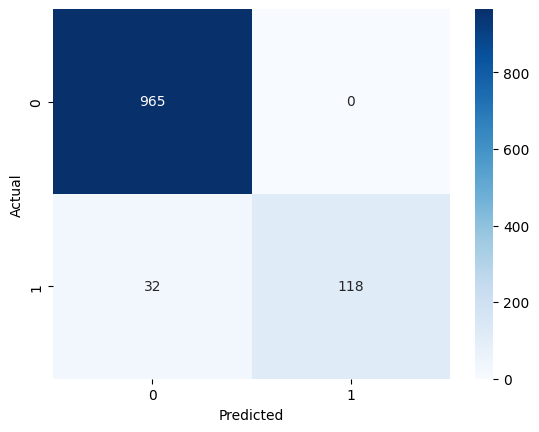

In [ ]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [ ]:
email = ["Congratulations! You won a free iPhone. Click here now."]

clean = preprocess(email[0])

vector = tfidf.transform([clean])

prediction = model.predict(vector)

if prediction[0]==1:
    print("Spam Email")
else:
    print("Not Spam")

Spam Email


In [ ]:
email = ["Hi team, the meeting is scheduled tomorrow at 10 AM."]

clean = preprocess(email[0])

vector = tfidf.transform([clean])

prediction = model.predict(vector)

if prediction[0]==1:
    print("Spam Email")
else:
    print("Not Spam")

Not Spam


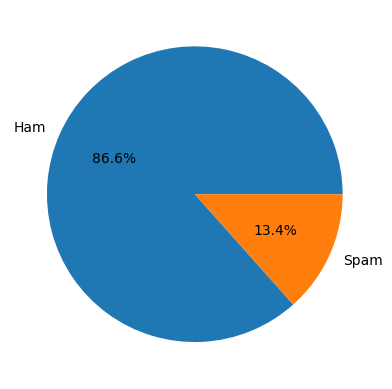

In [ ]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam']
)

plt.ylabel("")
plt.show()

In [ ]:
from collections import Counter

spam_text = " ".join(df[df['label']==1]['clean_email'])

words = spam_text.split()

counter = Counter(words)

print(counter.most_common(20))

[('call', 368), ('å', 270), ('free', 219), ('txt', 163), ('u', 155), ('ur', 144), ('text', 139), ('mobil', 136), ('stop', 116), ('claim', 115), ('repli', 110), ('prize', 94), ('get', 87), ('tone', 73), ('nokia', 72), ('servic', 72), ('p', 70), ('send', 69), ('new', 69), ('award', 66)]


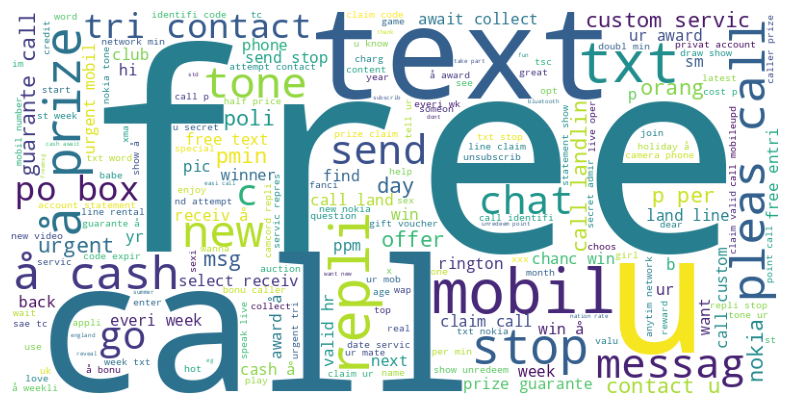

In [ ]:
from wordcloud import WordCloud

spam_text = " ".join(df[df['label']==1]['clean_email'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_text)

plt.figure(figsize=(10,5))

plt.imshow(wc)

plt.axis("off")

plt.show()